# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook:** c24_28 — Optimizer Pipeline Workflow  
**Author:** Jasper Cluistra  
**Last Updated:** 2026-05-17

---

### Goal
Step-by-step walkthrough of the full optimizer pipeline for a single design candidate. Useful for debugging individual stages, inspecting intermediate outputs, and verifying that module changes behave correctly before running the full GA.

### Pipeline stages
| Stage | Module | Description |
|-------|--------|-------------|
| 1 | Setup | Load stock, search space, path configuration |
| 2 | Geometry | Generate random design, compute member topology |
| 3 | Feasibility | EC5 filter - eliminate infeasible slot—stock pairs |
| 4 | Cost matrix | Compute CO2 kg assignment costs |
| 5 | MILP | Solve optimal stock assignment |
| 6 | GNN | Predict structural feasibility per member |
| 7 | Fitness | Compute normalised multi-objective fitness score |
| 8 | Export | Write vertices, edges, and assignment results to disk |

# 1. Setup
Resolve paths, load stock and search space. Set `MODEL_PREFIX` to a trained surrogate prefix to enable the GNN stage; leave as `None` to skip it.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (candidate / "config.py").exists():
        REPO_ROOT = candidate
        break

SRC_PATH       = REPO_ROOT / "src"
WORKFLOWS_PATH = REPO_ROOT / "workflows"
for path in (REPO_ROOT, SRC_PATH, WORKFLOWS_PATH):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import config
import c00_headquarter_params as c11_params

MODEL_PREFIX = "ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863"  # e.g. "ID20260516_182257_LR1e-04_EP200_BS64_PW2.5_ROC0.863"

# ── Search space ──────────────────────────────────────────────────────
json_path = config.DATA_IO_PATH / f"search_space_{c11_params.GRID}.json"
if not json_path.exists():
    raise FileNotFoundError(
        f"search_space_{c11_params.GRID}.json not found. "
        "Run c12_15 to generate it."
    )
with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)
print(f"Search space loaded: {len(optimizer_search_space)} variables")

# ── Stock ────────────────────────────────────────────────────────────
stock_path = config.TIMBER_STOCK_PATH / "complete_timber_A.csv"
if not stock_path.exists():
    raise FileNotFoundError(f"Stock CSV not found: {stock_path}. Run c16 to generate it.")

df_input_stock = None
for opts in [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]:
    try:
        _df = pd.read_csv(stock_path, **opts)
        if _df.shape[1] > 1:
            df_input_stock = _df
            print(f"Stock loaded: {len(_df)} elements  (sep='{opts['sep']}', encoding='{opts['encoding']}')")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse stock CSV with tested delimiter/encoding combinations.")

df_input_stock.columns = df_input_stock.columns.str.strip()
display(df_input_stock.head(3))

Config System loaded successfully, Code running locally from thesis_generative_timber and Data is connected to OneDrive 2.2 - 2.4.

Grid: 5x3, edge=3.0 m, height=1.5 m, divisions=8, samples=20000
LCA factors: A1-A3=0.25, C1=0.0085, A5 prep=0.01, A5 saw=0.004, C2 dist=50 km, C3-C4=0.031, ω=0
Search space loaded: 73 variables
Stock loaded: 522 elements  (sep=';', encoding='utf-8')


,Member_ID,State,Length,Depth,Width,Length_Category,Availability_Probability,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor,Donor_Role,Cut_Loss_mm
0,NS_00000,0,1800.0,100.0,38.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,323.62,0.1747,NaN,NaN
1,NS_00001,0,1800.0,100.0,50.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,48.35,0.1753,NaN,NaN
2,NS_00002,0,1800.0,100.0,63.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,256.40,0.1775,NaN,NaN


# 2. Geometry
Generate a random design candidate and compute the truss topology (nodes, members, lengths).

Geometry: 39 nodes, 120 members
Length range [m]: 1.125 - 5.250


,edge_id,V1,V2,length_m
0,e0,0,1,3.375
1,e1,0,6,3.750
2,e2,1,2,1.500
3,e3,1,7,2.281
4,e4,2,3,3.000


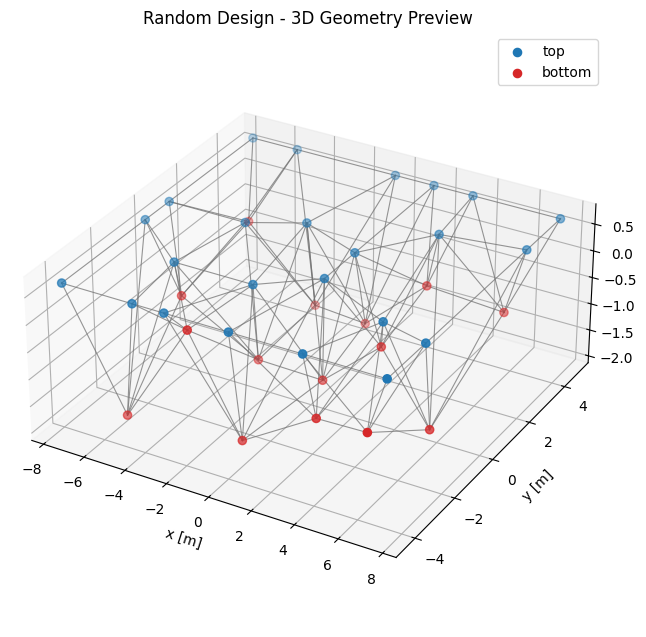

In [2]:
import matplotlib.pyplot as plt
import config
import c22_stage_geometry as stage_geometry

geometry_out = stage_geometry.run_random_geometry_stage(
    json_path=json_path if "json_path" in globals() else None,
    optimizer_search_space=optimizer_search_space if "optimizer_search_space" in globals() else None,
    sample_id=0,
)

my_random_design = geometry_out["my_random_design"]
vertices_list = geometry_out["vertices_list"]
df_vertices = geometry_out["df_vertices"]
df_edges = geometry_out["df_edges"]
df_geometry_overview = geometry_out["df_geometry_overview"]

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(5))

df_vertices.to_csv(config.DATA_IO_PATH / "df_vertices.csv", index=False)
df_edges.to_csv(config.DATA_IO_PATH / "df_edges.csv", index=False)

fig, ax = stage_geometry.plot_geometry_preview(
    df_vertices=df_vertices,
    df_edges=df_edges,
    figsize=(8, 7),
)
plt.show()

# 3-7. Pipeline stages
Run the full pipeline on the geometry from section 2: feasibility filter â†’ cost matrix â†’ MILP â†’ GNN â†’ fitness.

In [3]:
import importlib
import json
import pandas as pd
import config
from workflows import c25_stage_cost_matrix as stage_cost
from workflows import c26_stage_MILP as stage_milp

importlib.reload(stage_cost)
importlib.reload(stage_milp)

import numpy as np
from workflows import c24_stage_feasibility as stage_feas

verts = df_vertices[df_vertices['sample_id'] == 0].copy()
verts['v_idx'] = verts['vertex_index'].str.replace('v', '').astype(int)
verts = verts.sort_values('v_idx').reset_index(drop=True)
node_positions = verts[['x', 'y', 'z']].values   # [39, 3] metres

support_nodes = verts[verts['attribute'] == 'support']['v_idx'].tolist()
load_nodes    = verts[verts['attribute'] == 'load']['v_idx'].tolist()

print(f"Geometry loaded:")
print(f"  Nodes: {len(verts)}, Members: {len(df_edges)}")
print(f"  Support nodes: {support_nodes}")
print(f"  Load nodes: {load_nodes}")
print()

df_slots, feasibility_mask, member_forces, stats = stage_feas.build_cost_filter(
    node_positions=node_positions,
    edges_df=df_edges,
    stock_df=df_input_stock,
    support_nodes=support_nodes,
    load_nodes=load_nodes,
)
# display summary statistics about the feasibility filter results
print("\n" + "="*70)
print("FEASIBILITY FILTER SUMMARY")
print("="*70)
for k, v in stats.items():
    if isinstance(v, list):
        print(f"  {k:<35} {v}")
    elif isinstance(v, float):
        print(f"  {k:<35} {v:.4f}")
    else:
        print(f"  {k:<35} {v}")

print()
print(f"Member forces:")
print(f"  Tension     (N > 0): {(member_forces >  1.0).sum()} members")
print(f"  Compression (N < 0): {(member_forces < -1.0).sum()} members")
print(f"  Near-zero:           {(np.abs(member_forces) <= 1.0).sum()} members")
print(f"  Max tension:         {member_forces.max()/1000:.2f} kN")
print(f"  Max compression:     {member_forces.min()/1000:.2f} kN")

print("\nFeasibility mask ready for cost matrix filtering")

Geometry loaded:
  Nodes: 39, Members: 120
  Support nodes: [0, 5, 18, 23]
  Load nodes: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22]

  Stage 1 (length):    42,799 eliminated  (19,841 remaining, 31.7%)
  Stage 2 (force):   max tension=18.5 kN  max compression=-26.0 kN  mean |F|=4.4 kN
  Stage 3 (EC5):        1,622 eliminated  (18,219 remaining, 29.1%)

FEASIBILITY FILTER SUMMARY
  total_combinations                  62640
  after_length_filter                 19841
  after_structural_filter             18219
  pct_feasible                        29.0852
  slots_no_feasible_stock             []
  n_tension_members                   27
  n_compression_members               67
  max_tension_kn                      18.4869
  max_compression_kn                  -26.0459
  ec5_elim_slenderness                24
  ec5_elim_depth_ratio                89
  ec5_elim_width_ratio                1359
  ec5_elim_strength                   150

Member forces:
  Tension   

In [4]:
# STEP 1: COST MATRIX STAGE
cost_matrix, stock_prepared, logs = stage_cost.build_cost_matrix(
    df_slots=df_slots,
    df_input_stock=df_input_stock,
    feasibility_mask=feasibility_mask,
)

cost_matrix_df = pd.DataFrame(cost_matrix)
cost_matrix_df.to_csv(config.EXPORT_PATH / "c26_cost_matrix.csv")

# STEP 2: MILP STAGE
print("Starting MILP optimizer...")
milp_out = stage_milp.run_milp_stage(
    cost_matrix=cost_matrix,
    enriched_stock=stock_prepared,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    new_stock_max_uses=100,
    solver_msg=False,
    raise_on_infeasible_slots=False,
    )

status = milp_out.get("status")
df_results = milp_out.get("df_results", pd.DataFrame())
total_cost = milp_out.get("total_cost", float("inf"))
milp_summary = milp_out.get("summary", {})

df_results.to_csv(config.EXPORT_PATH / "c27_milp_results.csv", index=False)

print(
    f"MILP setup: {milp_summary.get('reclaimed_items', 0)} reclaimed + "
    f"{milp_summary.get('new_items', 0)} new stock items for {milp_summary.get('slots', len(df_slots))} slots"
)
print(f"MILP status: {status}")
print(f"Total assignment cost: {total_cost:.2f}")
if status != "Optimal":
    print("MILP did not solve to an optimal assignment for this geometry and stock set.")
if len(df_results) > 0:
    display(df_results.head(10))

Starting MILP optimizer...
MILP setup: 101 reclaimed + 421 new stock items for 120 slots
MILP status: Optimal
Total assignment cost: 123.29


,edge_id,assigned_timber,CO2_Penalty
0,e0,NS_00294,1.387524
1,e1,NS_00405,1.541383
2,e2,RS_00096,0.210311
3,e3,RS_00061,0.488227
4,e4,RS_00075,0.294061
5,e5,RS_00060,0.464718
6,e6,NS_00294,1.387524
7,e7,NS_00294,1.462578
8,e8,NS_00405,1.541383
9,e9,RS_00070,0.426644


# 4b. Cost breakdown — RS vs NS analysis
Rebuilds the cost matrix with full logs enabled to decompose each LCA component for reclaimed (RS) vs new (NS) stock. Shows why RS elements cost more (or less) than NS on a per-slot basis.

LCA factors used:
  A1-A3 embodied:    0.25
  C1 recovery:       0.0085
  A5 prep:           0.01
  A5 saw:            0.004
  C2 waste dist:     50 km
  C3-C4 offcut:      0.031
  Scarcity penalty:  0

Feasible pairs:  NS=14,234  RS=3,985

Mean LCA cost per feasible slot×stock pair (kg CO2e):
           E_embodied  E_recovered  E_transport   E_prep    E_saw  E_waste  E_scarcity  Total cost
Branch                                                                                            
new           1.23324      0.00000      0.17170  0.00000  0.00000   0.0000         0.0     1.40494
reclaimed     0.00000      0.22524      0.43643  0.26499  0.10597   0.1883         0.0     1.22093

Per-slot comparison:
  Slots with >=1 RS option:      115
  RS cheaper than best NS:       92  (80.0%)
  RS more expensive than NS:     23  (20.0%)
  Mean NS min cost:              1.2841 kg CO2e
  Mean RS min cost:              0.8550 kg CO2e
  Mean RS premium (RS - NS):    -0.4290 kg CO2e
  Mean RS waste 

C:\Users\VR Guest\AppData\Local\Temp\ipykernel_19508\3914584818.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


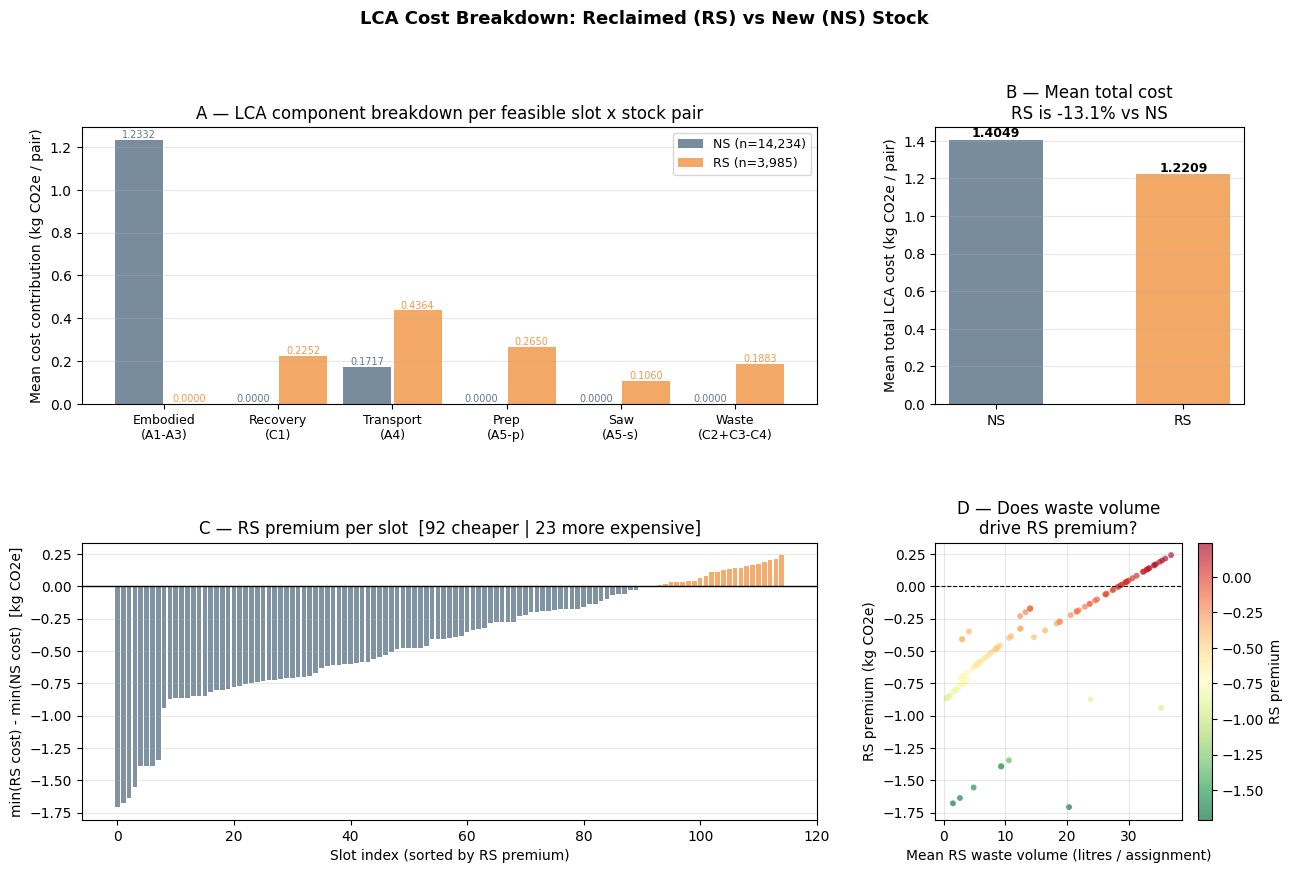

In [5]:
import importlib
import numpy as np
import pandas as pd
import config
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from workflows import c25_stage_cost_matrix as stage_cost
importlib.reload(stage_cost)

import c00_headquarter_params as _p

# Rebuild cost matrix with detailed logs (build_logs=False in the GA loop for speed)
_, _, df_logs = stage_cost.build_cost_matrix(
    df_slots         = df_slots,
    df_input_stock   = df_input_stock,
    feasibility_mask = feasibility_mask,
    build_logs       = True,
    prepared_stock   = stock_prepared,
)

feasible = df_logs[df_logs["Feasible"]].copy()
n_rs = (feasible["Branch"] == "reclaimed").sum()
n_ns = (feasible["Branch"] == "new").sum()

COMPONENTS = ["E_embodied", "E_recovered", "E_transport", "E_prep", "E_saw", "E_waste", "E_scarcity"]
LABELS     = ["Embodied\n(A1-A3)", "Recovery\n(C1)", "Transport\n(A4)", "Prep\n(A5-p)", "Saw\n(A5-s)", "Waste\n(C2+C3-C4)", "Scarcity"]

by_branch = feasible.groupby("Branch")[COMPONENTS + ["Total cost"]].mean()

print("LCA factors used:")
print(f"  A1-A3 embodied:    {_p.IMPACT_FACTOR_A1_A3}")
print(f"  C1 recovery:       {_p.IMPACT_FACTOR_RECOVERED_C1}")
print(f"  A5 prep:           {_p.ENERGY_PREP_A5}")
print(f"  A5 saw:            {_p.ENERGY_SAW_A5}")
print(f"  C2 waste dist:     {_p.WASTE_TRANSPORT_DIST_KM} km")
print(f"  C3-C4 offcut:      {_p.ENERGY_OFFCUT_FACTOR_C3_C4}")
print(f"  Scarcity penalty:  {_p.SCARCITY_PENALTY}")
print()
print(f"Feasible pairs:  NS={n_ns:,}  RS={n_rs:,}")
print()
print("Mean LCA cost per feasible slot×stock pair (kg CO2e):")
print(by_branch[COMPONENTS + ["Total cost"]].round(5).to_string())

rs_min   = feasible[feasible["Branch"]=="reclaimed"].groupby("Slot_ID")["Total cost"].min().rename("RS_min")
ns_min   = feasible[feasible["Branch"]=="new"      ].groupby("Slot_ID")["Total cost"].min().rename("NS_min")
rs_count = feasible[feasible["Branch"]=="reclaimed"].groupby("Slot_ID")["Total cost"].count().rename("RS_options")
rs_waste = feasible[feasible["Branch"]=="reclaimed"].groupby("Slot_ID")["V_waste_m3"].mean().rename("RS_mean_waste_m3")

slot_cmp = pd.concat([ns_min, rs_min, rs_count, rs_waste], axis=1)
slot_cmp_both = slot_cmp.dropna(subset=["NS_min", "RS_min"]).copy()
slot_cmp_both["RS_premium"] = slot_cmp_both["RS_min"] - slot_cmp_both["NS_min"]
slot_cmp_both["RS_cheaper"] = slot_cmp_both["RS_premium"] < 0

n_slots_total   = len(df_slots)
n_slots_with_rs = len(rs_min)
n_rs_cheaper    = int(slot_cmp_both["RS_cheaper"].sum())
n_rs_pricier    = len(slot_cmp_both) - n_rs_cheaper

print()
print("Per-slot comparison:")
print(f"  Slots with >=1 RS option:      {n_slots_with_rs}")
print(f"  RS cheaper than best NS:       {n_rs_cheaper}  ({100*n_rs_cheaper/len(slot_cmp_both):.1f}%)")
print(f"  RS more expensive than NS:     {n_rs_pricier}  ({100*n_rs_pricier/len(slot_cmp_both):.1f}%)")
print(f"  Mean NS min cost:              {slot_cmp_both['NS_min'].mean():.4f} kg CO2e")
print(f"  Mean RS min cost:              {slot_cmp_both['RS_min'].mean():.4f} kg CO2e")
print(f"  Mean RS premium (RS - NS):    {slot_cmp_both['RS_premium'].mean():+.4f} kg CO2e")
print(f"  Mean RS waste volume:          {slot_cmp_both['RS_mean_waste_m3'].mean()*1000:.2f} L / assignment")

if "new" in by_branch.index and "reclaimed" in by_branch.index:
    ns_total = float(by_branch.loc["new",       "Total cost"])
    rs_total = float(by_branch.loc["reclaimed", "Total cost"])
    print()
    print(f"  NS mean total:  {ns_total:.5f}")
    print(f"  RS mean total:  {rs_total:.5f}  ({'+' if rs_total>ns_total else ''}{100*(rs_total-ns_total)/ns_total:.1f}% vs NS)")
    for comp, lbl in zip(COMPONENTS, LABELS):
        ns_v = float(by_branch.loc["new",       comp]) if "new"       in by_branch.index else 0.0
        rs_v = float(by_branch.loc["reclaimed", comp]) if "reclaimed" in by_branch.index else 0.0
        marker = " <--" if rs_v > ns_v * 1.5 + 1e-6 else ""
        print(f"  {lbl.replace(chr(10),' '):<20}  NS={ns_v:.5f}  RS={rs_v:.5f}{marker}")

C_NS = config.PLOT_COLORS["NS"]
C_RS = config.PLOT_COLORS["RS"]

fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

# Panel A — grouped bar LCA components
ax0 = fig.add_subplot(gs[0, :2])
active = [c for c in COMPONENTS if by_branch[c].abs().max() > 1e-7]
active_lbl = [LABELS[COMPONENTS.index(c)] for c in active]
x = np.arange(len(active))
ns_vals = [float(by_branch.loc["new",       c]) if "new"       in by_branch.index else 0.0 for c in active]
rs_vals = [float(by_branch.loc["reclaimed", c]) if "reclaimed" in by_branch.index else 0.0 for c in active]
bars_ns = ax0.bar(x - 0.22, ns_vals, 0.42, label=f"NS (n={n_ns:,})", color=C_NS, alpha=0.85)
bars_rs = ax0.bar(x + 0.22, rs_vals, 0.42, label=f"RS (n={n_rs:,})", color=C_RS, alpha=0.85)
ax0.set_xticks(x); ax0.set_xticklabels(active_lbl, fontsize=9)
ax0.set_ylabel("Mean cost contribution (kg CO2e / pair)")
ax0.set_title("A — LCA component breakdown per feasible slot x stock pair")
ax0.legend(fontsize=9); ax0.grid(axis="y", alpha=0.3)
for bar in bars_ns: ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7, color=C_NS)
for bar in bars_rs: ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0001, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7, color=C_RS)

# Panel B — total cost comparison
ax1 = fig.add_subplot(gs[0, 2])
ns_t = float(by_branch.loc["new",       "Total cost"]) if "new"       in by_branch.index else 0.0
rs_t = float(by_branch.loc["reclaimed", "Total cost"]) if "reclaimed" in by_branch.index else 0.0
ax1.bar(["NS", "RS"], [ns_t, rs_t], color=[C_NS, C_RS], alpha=0.85, width=0.5)
ax1.set_ylabel("Mean total LCA cost (kg CO2e / pair)")
pct = 100 * (rs_t - ns_t) / ns_t if ns_t > 1e-9 else 0
ax1.set_title(f"B — Mean total cost\nRS is {pct:+.1f}% vs NS")
for i, v in enumerate([ns_t, rs_t]): ax1.text(i, v+0.0002, f"{v:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Panel C — RS premium per slot sorted
ax2 = fig.add_subplot(gs[1, :2])
sorted_slots = slot_cmp_both.sort_values("RS_premium")
colors_bar   = [C_NS if v < 0 else C_RS for v in sorted_slots["RS_premium"]]
ax2.bar(range(len(sorted_slots)), sorted_slots["RS_premium"].values, color=colors_bar, alpha=0.8)
ax2.axhline(0, color="k", lw=1.0)
ax2.set_xlabel("Slot index (sorted by RS premium)")
ax2.set_ylabel("min(RS cost) - min(NS cost)  [kg CO2e]")
ax2.set_title(f"C — RS premium per slot  [{n_rs_cheaper} cheaper | {n_rs_pricier} more expensive]")
ax2.grid(axis="y", alpha=0.3)

# Panel D — waste volume vs RS premium
ax3 = fig.add_subplot(gs[1, 2])
sc = ax3.scatter(slot_cmp_both["RS_mean_waste_m3"]*1000, slot_cmp_both["RS_premium"],
                 c=slot_cmp_both["RS_premium"], cmap="RdYlGn_r", alpha=0.65, s=18, edgecolors="none")
ax3.axhline(0, color="k", lw=0.8, linestyle="--")
ax3.set_xlabel("Mean RS waste volume (litres / assignment)")
ax3.set_ylabel("RS premium (kg CO2e)")
ax3.set_title("D — Does waste volume\ndrive RS premium?")
fig.colorbar(sc, ax=ax3, label="RS premium")
ax3.grid(alpha=0.3)

fig.suptitle("LCA Cost Breakdown: Reclaimed (RS) vs New (NS) Stock", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [6]:
import c27_stage_GNN as stage_gnn
from c21_surrogate_io import load_surrogate_bundle

model_bundle = None
milp_status = milp_out.get("status")
milp_assignment = milp_out.get("milp_assignment")

if milp_status != "Optimal" or milp_assignment is None:
    print(f"Skipping GNN stage because MILP status is {milp_status!r}.")
elif MODEL_PREFIX:
    print(f"Loading surrogate model bundle with prefix: {MODEL_PREFIX}")
    model_bundle = load_surrogate_bundle(prefix_sm=MODEL_PREFIX)
else:
    model_bundle = globals().get("model_bundle")
    if model_bundle is None:
        print("No MODEL_PREFIX set and no model_bundle loaded; skipping GNN stage.")

if model_bundle is None:
    gnn_out = {
        "feasibility_score": 1.0,
        "structural_penalty": 0.0,
        "unsafe_member_ids": [],
    }
else:
    gnn_out = stage_gnn.run_gnn_stage(
        node_positions=node_positions,
        milp_assignment=milp_assignment,
        df_input_stock=df_input_stock,
        model_bundle=model_bundle,
    )

feasibility_score = float(gnn_out.get("feasibility_score", 1.0))
structural_penalty = float(gnn_out.get("structural_penalty", 0.0))
unsafe_member_ids = gnn_out.get("unsafe_member_ids", [])

print(f"\nGNN Feasibility Results:")
print(f"  Feasibility score:  {feasibility_score:.4f}  (1.0 = all members predicted safe)")
print(f"  Unsafe members:     {len(unsafe_member_ids)} / {stage_gnn.NUM_EDGES_PHYSICAL}")
print(f"  Structural penalty: {structural_penalty:.4f}  (w_structural=0.3)")
if unsafe_member_ids:
    print(f"  Unsafe member IDs:  {unsafe_member_ids[:20]}{'...' if len(unsafe_member_ids) > 20 else ''}")


c:\Users\VR Guest\Documents\PyRepo\thesis_generative_timber\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Skipping GNN stage because MILP status is 'Optimal'.

GNN Feasibility Results:
  Feasibility score:  1.0000  (1.0 = all members predicted safe)
  Unsafe members:     0 / 120
  Structural penalty: 0.0000  (w_structural=0.3)


In [7]:
from workflows.c28_stage_fitness_score import run_fitness_stage
from workflows.c28_stage_normalization_bounds import run_normalization_bounds_stage

# ── Normalisation bounds ──────────────────────────────────────────────────────
bounds_out = run_normalization_bounds_stage(
    cost_matrix        = cost_matrix,
    df_logs            = globals().get('df_logs', logs),
    enriched_stock     = stock_prepared,
    df_slots           = df_slots,
    reclaimed_marker   = "RS",
    new_marker         = "NS",
    new_stock_max_uses = 100,
    solver_msg         = False,
    print_summary      = True,
)
normalization_constants = bounds_out["normalization_constants"]
print(normalization_constants)

# ── Fitness weights ───────────────────────────────────────────────────────────
# Single-shot evaluation — omega_4 fixed at w_start. The GA schedules it dynamically.
w_start = 0.2
w_end   = 0.8

fitness_weights = {
    "omega_1": 1.0,
    "omega_2": 1.0,
    "omega_3": 1.0,
    "omega_4": w_start,
}

# ── Fitness stage ─────────────────────────────────────────────────────────────
if df_results.empty:
    print("Skipping fitness stage — MILP returned no assignments.")
    fitness_result = {"objective": None, "is_feasible": False, "fitness": float("inf")}
    fitness_out = {"fitness_result": fitness_result, "normalization_constants": normalization_constants}
else:
    fitness_out = run_fitness_stage(
        df_results               = df_results,
        enriched_stock           = stock_prepared,
        df_slots                 = df_slots,
        total_cost               = total_cost,
        weight_config            = fitness_weights,
        normalization_constants  = normalization_constants,
        structural_infeasibility = 1.0 - feasibility_score,
        derive_normalization_constants = False,
        run_sanity_checks        = True,
        print_breakdown          = True,
    )
    fitness_result          = fitness_out["fitness_result"]
    normalization_constants = fitness_out["normalization_constants"]

fitness_export = dict(fitness_out)

print(f"\nFitness summary:")
print(f"  objective: {fitness_result.get('objective', 'n/a')}")
print(f"  feasible:  {fitness_result.get('is_feasible', 'n/a')}")
print(f"  fitness:   {fitness_result.get('fitness', 'n/a')}")

# ── Export ────────────────────────────────────────────────────────────────────
fitness_json_path = config.EXPORT_PATH / "c28_fitness_result.json"
fitness_csv_path  = config.EXPORT_PATH / "c28_fitness_result.csv"
fitness_json_path.parent.mkdir(parents=True, exist_ok=True)

def _to_builtin(value):
    return value.item() if hasattr(value, "item") else value

can_export = (not df_results.empty) and all(
    v == v and v not in (float("inf"), float("-inf"))
    for v in normalization_constants.values()
)

if can_export:
    fitness_export.pop("weights", None)
    fitness_export["weights"] = {k: float(v) for k, v in fitness_weights.items()}
    fitness_export["normalization_constants"] = {k: float(v) for k, v in normalization_constants.items()}
    with open(fitness_json_path, "w", encoding="utf-8") as f:
        json.dump(fitness_export, f, indent=2)
    fitness_row = {
        **{k: _to_builtin(v) for k, v in fitness_result.items()},
        **fitness_weights,
        **{k: float(v) for k, v in normalization_constants.items()},
    }
    pd.DataFrame([fitness_row]).to_csv(fitness_csv_path, index=False)
    print(f"\nExported: {fitness_json_path.name}, {fitness_csv_path.name}")
else:
    print("Skipping fitness export — pipeline infeasible or normalisation bounds unavailable.")


Bounds status: Optimal
Normalization constants C_max=212.74396784328488, R_max=0.6234337336303307
{'C_max': 212.74396784328488, 'R_max': 0.6234337336303307}

MULTI-OBJECTIVE FITNESS EVALUATION

Raw Metrics:
  MILP Cost:               123.288 kg CO2e
  Reuse Fraction:            0.323  (volume-weighted, 0–1)
  Structural infeasible:     0.000  (fraction of unsafe members)

Normalized (0–1 range):
  Cost (norm):         0.580
  Reuse (norm):        0.518
  Structural:          0.000  (already in [0,1])

Weights Applied:
  omega_1 (cost):           1.000
  omega_2 (reuse):          1.000  (subtracted)
  omega_4 (structural):     0.200

Weighted Components:
  omega_1 x cost:           0.580
  omega_2 x reuse:      -   0.518
  omega_4 x structural:     0.000

Final Fitness (lower = better):
  F(x) = 0.580 - 0.518 + 0.000
  F(x) =    0.062

  is_feasible: True

Interpretation:
  [GOOD] Balanced trade-off with no major objective dominance
  Bands: ≤ -0.450 excellent, ≤ 0.100 good, ≤ 0.650 fai

# 8. Export
Write vertices and edges (with MILP assignments) to disk for Grasshopper reconstruction. Skipped if MILP returned no assignment.


In [8]:
EXPORT_PREFIX = "c29_optimum"

if any(name not in globals() for name in ["df_vertices", "df_edges", "df_results"]) or df_results.empty:
    print("Skipping structural export — no MILP assignment available.")
else:
    df_edges_export = pd.merge(
        df_edges,
        df_results[["edge_id", "assigned_timber", "CO2_Penalty"]],
        on="edge_id", how="left",
    )
    df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
    df_edges_export["CO2_Penalty"]     = df_edges_export["CO2_Penalty"].fillna(0)

    df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
    df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges.csv", index=False)

    n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
    print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")


Exported: 39 vertices, 120 edges (120 matched)


# 9. Sensitivity Analysis — Unsourced LCA Parameters
Three input factors (C1, A5-prep, A5-saw) have no primary literature source and are marked `[est.]` in `c00_headquarter_params.py`. This cell varies all three jointly from 0× to 2× their nominal values (a ±100 % range), re-solves the MILP for each scenario, and re-evaluates the fitness function with fixed normalisation constants. The resulting fitness range quantifies the maximum influence of the missing sources on the study's conclusions.

Baseline: C1=0.0085, A5_prep=0.01, A5_saw=0.004
Sweeping multipliers x nominal: [0.0, 0.5, 1.0, 1.5, 2.0]
Fixed normalisation constants: {'C_max': 212.74396784328488, 'R_max': 0.6234337336303307}

  0% of nominal           C1=0.00000  A5=0.0000  ->  F=-0.42474
  50% of nominal          C1=0.00425  A5=0.0050  ->  F=-0.16557
  100% of nominal         C1=0.00850  A5=0.0100  ->  F=0.06166
  150% of nominal         C1=0.01275  A5=0.0150  ->  F=0.27066
  200% of nominal         C1=0.01700  A5=0.0200  ->  F=0.36684

SENSITIVITY ANALYSIS -- C1 and A5 parameters (+-100% range)
       Scenario  MILP_cost_kgCO2e  Fitness_F      dF       dF%
  0% of nominal           90.7875    -0.4247 -0.4864 -788.8787
 50% of nominal          107.8698    -0.1656 -0.2272 -368.5396
100% of nominal          123.2876     0.0617  0.0000    0.0000
150% of nominal          135.3250     0.2707  0.2090  338.9857
200% of nominal          145.7752     0.3668  0.3052  494.9774


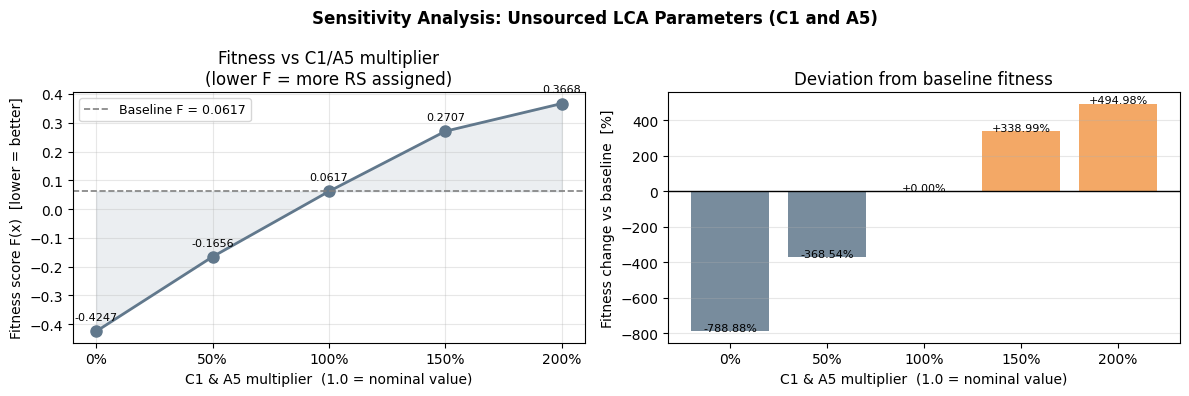

Three LCA input factors -- the selective-deconstruction energy penalty
- (C1 = 0.0085 kg CO2e/kg), the reclaimed-element preparation energy
- (A5-prep = 0.01 kg CO2e/kg), and the secondary cross-cut energy
- (A5-saw = 0.004 kg CO2e/kg) -- could not be sourced from primary

literature and are treated as engineering estimates (see Section X.X). Because these penalties apply exclusively to reclaimed stock,
they directly govern the competitive advantage of RS over NS in the MILP objective function:
- lower values make reclaimed elements cheaper, causing the optimizer to assign more of them, while higher values suppress reuse.

To make this dependency explicit, a scenario analysis was conducted by varying all three parameters jointly from 0x to 2x their nominal values and
re-solving the MILP for each case against fixed normalisation constants.The total assignment cost ranged from 90.8 kg CO2e (lower bound: zero
recovery penalty) to 145.8 kg CO2e (upper bound: double penalty), compared to a 

In [ ]:
import importlib
import numpy as np
import pandas as pd
import config
import matplotlib.pyplot as plt
import c00_headquarter_params as _p
from workflows import c25_stage_cost_matrix as stage_cost
from workflows import c26_stage_MILP as stage_milp
from workflows.c28_stage_fitness_score import run_fitness_stage

# Baseline values (read once, restored at the end)
BASE_C1   = _p.IMPACT_FACTOR_RECOVERED_C1   # 0.0085
BASE_PREP = _p.ENERGY_PREP_A5               # 0.01
BASE_SAW  = _p.ENERGY_SAW_A5                # 0.01

multipliers = [0.0, 0.5, 1.0, 1.5, 2.0]
records     = []

print(f"Baseline: C1={BASE_C1}, A5_prep={BASE_PREP}, A5_saw={BASE_SAW}")
print(f"Sweeping multipliers x nominal: {multipliers}")
print(f"Fixed normalisation constants: {normalization_constants}\n")

for mult in multipliers:
    _p.IMPACT_FACTOR_RECOVERED_C1 = BASE_C1   * mult
    _p.ENERGY_PREP_A5             = BASE_PREP * mult
    _p.ENERGY_SAW_A5              = BASE_SAW  * mult
    importlib.reload(stage_cost)

    cm, sp, _ = stage_cost.build_cost_matrix(
        df_slots         = df_slots,
        df_input_stock   = df_input_stock,
        feasibility_mask = feasibility_mask,
    )
    m_out = stage_milp.run_milp_stage(
        cost_matrix               = cm,
        enriched_stock            = sp,
        df_slots                  = df_slots,
        reclaimed_marker          = 'RS',
        new_marker                = 'NS',
        new_stock_max_uses        = 100,
        solver_msg                = False,
        raise_on_infeasible_slots = False,
    )
    tc = m_out.get('total_cost', float('inf'))
    dr = m_out.get('df_results', pd.DataFrame())

    if dr.empty:
        fitness = float('inf')
    else:
        f_out = run_fitness_stage(
            df_results                     = dr,
            enriched_stock                 = sp,
            df_slots                       = df_slots,
            total_cost                     = tc,
            weight_config                  = fitness_weights,
            normalization_constants        = normalization_constants,
            structural_infeasibility       = 0.0,
            derive_normalization_constants = False,
            run_sanity_checks              = False,
            print_breakdown                = False,
        )
        fitness = f_out['fitness_result']['fitness']

    label = f"{int(mult * 100)}% of nominal"
    records.append({"Multiplier": mult, "Scenario": label, "MILP_cost_kgCO2e": tc, "Fitness_F": fitness})
    print(f"  {label:<22}  C1={_p.IMPACT_FACTOR_RECOVERED_C1:.5f}  A5={_p.ENERGY_PREP_A5:.4f}  ->  F={fitness:.5f}")

# Restore module to baseline
_p.IMPACT_FACTOR_RECOVERED_C1 = BASE_C1
_p.ENERGY_PREP_A5             = BASE_PREP
_p.ENERGY_SAW_A5              = BASE_SAW
importlib.reload(stage_cost)

# Results table
df_sens        = pd.DataFrame(records)
base_fitness   = float(df_sens[df_sens["Multiplier"] == 1.0]["Fitness_F"].iloc[0])
df_sens["dF"]  = df_sens["Fitness_F"] - base_fitness
df_sens["dF%"] = 100.0 * df_sens["dF"] / abs(base_fitness)

low_f  = float(df_sens[df_sens["Multiplier"] == 0.0]["Fitness_F"].iloc[0])
high_f = float(df_sens[df_sens["Multiplier"] == 2.0]["Fitness_F"].iloc[0])
low_c  = float(df_sens[df_sens["Multiplier"] == 0.0]["MILP_cost_kgCO2e"].iloc[0])
high_c = float(df_sens[df_sens["Multiplier"] == 2.0]["MILP_cost_kgCO2e"].iloc[0])
base_c = float(df_sens[df_sens["Multiplier"] == 1.0]["MILP_cost_kgCO2e"].iloc[0])

print("\n" + "="*72)
print("SENSITIVITY ANALYSIS -- C1 and A5 parameters (+-100% range)")
print("="*72)
print(df_sens[["Scenario", "MILP_cost_kgCO2e", "Fitness_F", "dF", "dF%"]].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"
))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pct_ticks = [f"{int(m*100)}%" for m in multipliers]
primary = config.PLOT_COLORS["primary"]
accent  = config.PLOT_COLORS["accent"]

ax = axes[0]
ax.plot(pct_ticks, df_sens["Fitness_F"].values, "o-", color=primary, lw=2, ms=8)
ax.axhline(base_fitness, color="gray", lw=1.2, linestyle="--", label=f"Baseline F = {base_fitness:.4f}")
ax.fill_between(pct_ticks, df_sens["Fitness_F"].values, base_fitness, alpha=0.12, color=primary)
for x_, y_ in zip(pct_ticks, df_sens["Fitness_F"].values):
    ax.annotate(f"{y_:.4f}", (x_, y_), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_xlabel("C1 & A5 multiplier  (1.0 = nominal value)")
ax.set_ylabel("Fitness score F(x)  [lower = better]")
ax.set_title("Fitness vs C1/A5 multiplier\n(lower F = more RS assigned)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
bar_colors = [accent if v > 0 else primary for v in df_sens["dF%"].values]
ax.bar(pct_ticks, df_sens["dF%"].values, color=bar_colors, alpha=0.85)
ax.axhline(0, color="k", lw=1.0)
ax.set_xlabel("C1 & A5 multiplier  (1.0 = nominal value)")
ax.set_ylabel("Fitness change vs baseline  [%]")
ax.set_title("Deviation from baseline fitness")
ax.grid(axis="y", alpha=0.3)
for x_, y_ in zip(pct_ticks, df_sens["dF%"].values):
    ax.text(x_, y_ + (0.3 if y_ >= 0 else -0.6), f"{y_:+.2f}%", ha="center", fontsize=8)

plt.suptitle("Sensitivity Analysis: Unsourced LCA Parameters (C1 and A5)", fontweight="bold")
plt.tight_layout()
plt.savefig(config.EXPORT_PATH / "c24_sensitivity_C1_A5.png", dpi=150, bbox_inches="tight")
plt.show()

# Thesis paragraph -- scenario-analysis framing
print(
    f"Three LCA input factors -- the selective-deconstruction energy penalty\n"
    f"- (C1 = {BASE_C1} kg CO2e/kg), the reclaimed-element preparation energy\n"
    f"- (A5-prep = {BASE_PREP} kg CO2e/kg), and the secondary cross-cut energy\n"
    f"- (A5-saw = {BASE_SAW} kg CO2e/kg) -- could not be sourced from primary\n"
    f"\nliterature and are treated as engineering estimates (see Section X.X). Because these penalties apply exclusively to reclaimed stock,\n"
    f"they directly govern the competitive advantage of RS over NS in the MILP objective function:\n"
    f"- lower values make reclaimed elements cheaper, causing the optimizer to assign more of them, while higher values suppress reuse.\n"
    f"\nTo make this dependency explicit, a scenario analysis was conducted by varying all three parameters jointly from 0x to 2x their nominal values and\n"
    f"re-solving the MILP for each case against fixed normalisation constants.The total assignment cost ranged from {low_c:.1f} kg CO2e (lower bound: zero\n"
    f"recovery penalty) to {high_c:.1f} kg CO2e (upper bound: double penalty), compared to a nominal result of {base_c:.1f} kg CO2e.\n"
    f"\nThe fitness score correspondingly spanned from {low_f:.3f} to {high_f:.3f} (nominal: {base_fitness:.3f}), crossing multiple interpretation bands and\n"
    f"confirming that these parameters are load-bearing for the RS-NS trade-off. The nominal-scenario results reported throughout this study should therefore\n"
    f"be read alongside the lower-bound (0x) and upper-bound (2x) bracketing cases presented in Figure X.\n"
    f"\nSourcing primary per-kilogram data -- for example from "
    f"Bergman et al. (2010) for reclaimed lumber reprocessing, or from the NMD /\n"
    f"Okobaudat database for selective deconstruction energy -- is recommended as a priority for future work that aims to reduce this uncertainty.\n"
)
